In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [9]:
df=pd.read_csv("banknotes.csv")

In [10]:
df

,Variance,Skewness,Curtosis,Entropy,Class
0,3.62160,8.66610,-2.8073,-0.44699,0
1,4.54590,8.16740,-2.4586,-1.46210,0
2,3.86600,-2.63830,1.9242,0.10645,0
3,3.45660,9.52280,-4.0112,-3.59440,0
4,0.32924,-4.45520,4.5718,-0.98880,0
...,...,...,...,...,...
1367,0.40614,1.34920,-1.4501,-0.55949,1
1368,-1.38870,-4.87730,6.4774,0.34179,1
1369,-3.75030,-13.45860,17.5932,-2.77710,1
1370,-3.56370,-8.38270,12.3930,-1.28230,1


In [11]:
df.isnull().sum()

Variance    0
Skewness    0
Curtosis    0
Entropy     0
Class       0
dtype: int64

In [13]:
df.columns

Index(['Variance', 'Skewness', 'Curtosis', 'Entropy', 'Class'], dtype='object')

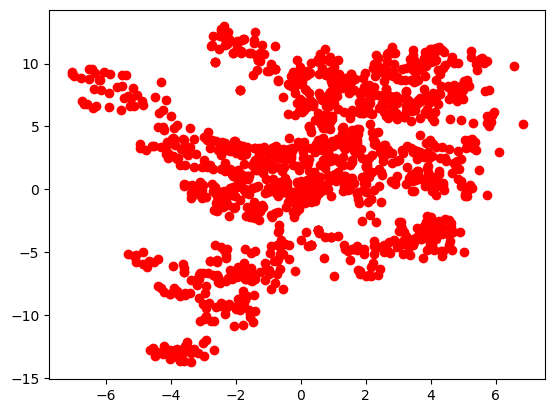

In [25]:
plt.scatter(df["Variance"],df['Skewness'],color="red")

In [26]:
import seaborn as sns

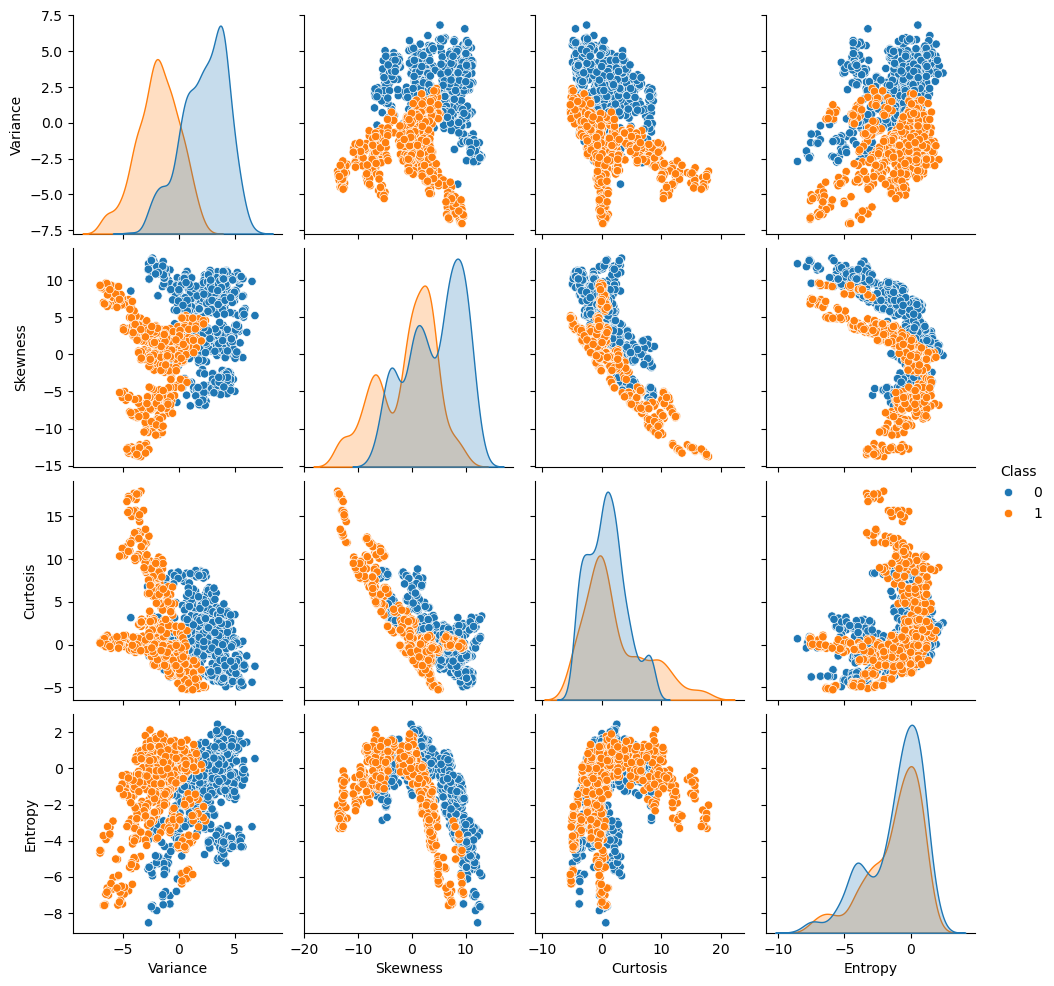

In [27]:
sns.pairplot(df,hue ="Class");

In [28]:
# check the distribution of target variable(countplot)

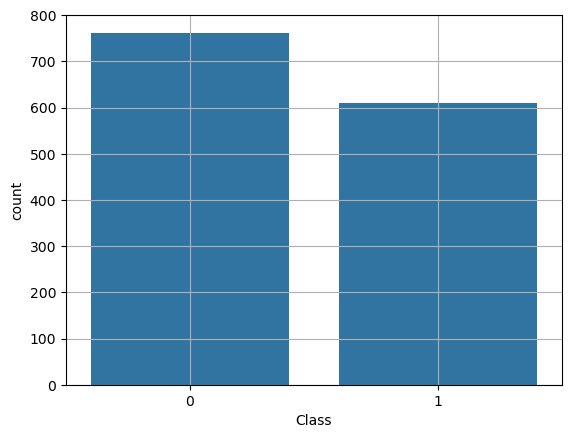

In [32]:
sns.countplot(x=df["Class"])
plt.grid()

In [33]:
x=df.drop("Class",axis=1)
y=df["Class"]

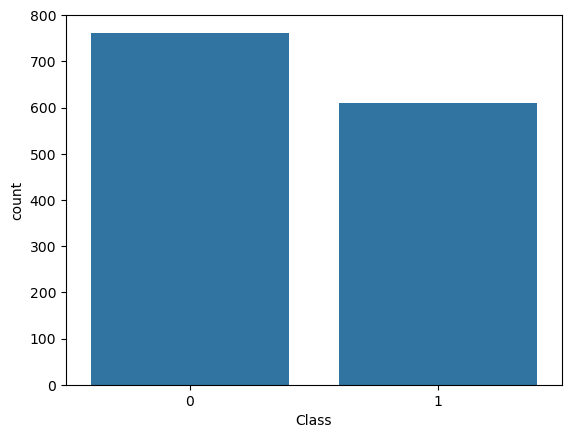

In [34]:
sns.countplot(x=y);

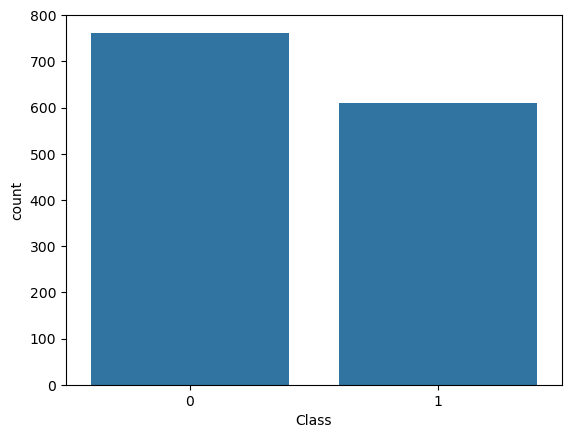

In [35]:
sns.countplot(x=y);

In [38]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [39]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)

In [41]:
model=LinearRegression()

In [42]:
model.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [44]:
x_train

,Variance,Skewness,Curtosis,Entropy
1282,-1.9983,-6.6072,4.82540,-0.419840
535,1.9476,-4.7738,8.52700,-1.866800
890,-1.6637,3.2881,-2.27010,-2.222400
1368,-1.3887,-4.8773,6.47740,0.341790
371,4.1529,-3.9358,2.86330,-0.017686
...,...,...,...,...
1095,1.1640,3.9130,-4.55440,-3.867200
1130,-2.2918,-7.2570,7.95970,0.921100
1294,-7.0364,9.2931,0.16594,-4.539600
860,-3.4605,2.6901,0.16165,-1.022400


In [46]:
x_train.shape,y_train.shape

((1029, 4), (1029,))

In [48]:
from sklearn.tree import DecisionTreeClassifier

In [49]:
x=df.drop("Class",axis=1)
y=df["Class"]

In [50]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)

In [51]:
model=DecisionTreeClassifier(random_state=42)

In [52]:
model.fit(x_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [59]:
from sklearn.metrics import accuracy_score,classification_report

In [60]:
y_pred=model.predict(x_test)

In [77]:
accuracy_score(y_test,y_pred)

0.9825072886297376

In [78]:
classification_report(y_test,y_pred)

'              precision    recall  f1-score   support\n\n           0       0.97      1.00      0.98       191\n           1       1.00      0.96      0.98       152\n\n    accuracy                           0.98       343\n   macro avg       0.98      0.98      0.98       343\nweighted avg       0.98      0.98      0.98       343\n'

In [79]:
# plot the graph to viz feature importance

Text(0, 0.5, 'Importance')

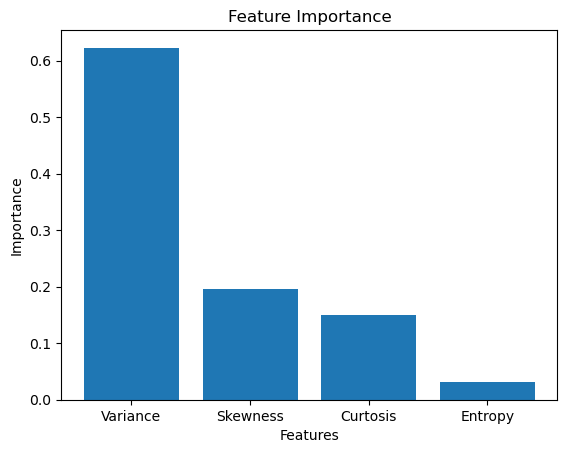

In [80]:
plt.title("Feature Importance")
plt.bar(x.columns, model.feature_importances_)
plt.xlabel("Features")
plt.ylabel("Importance")

In [81]:
from sklearn.tree import plot_tree

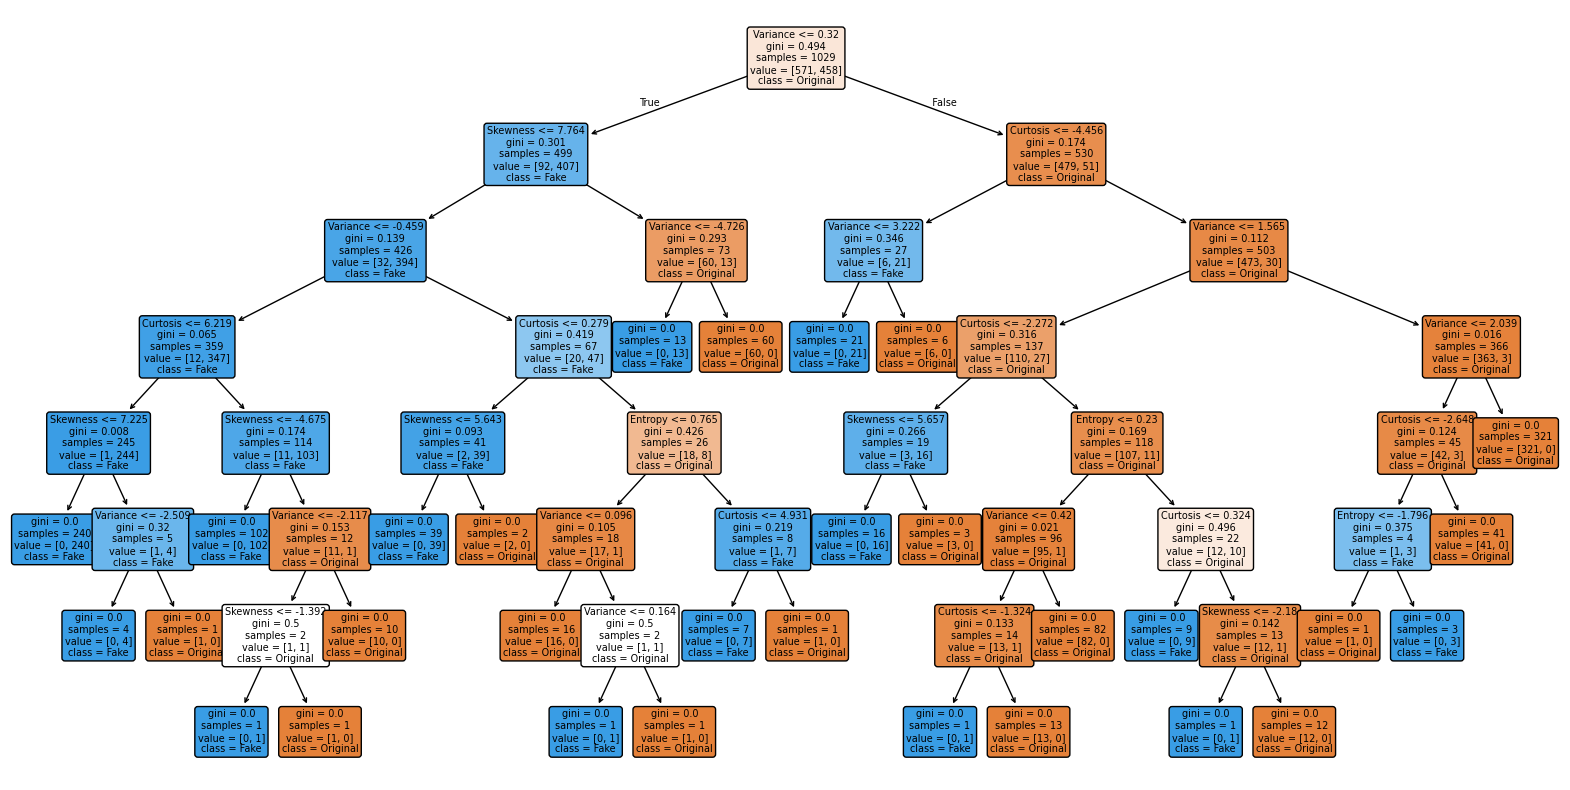

In [82]:
plt.figure(figsize=(20,10))
plot_tree(model,rounded=True,fontsize=7,filled=True,class_names=["Original","Fake"],feature_names=x.columns);

In [83]:
"""
4.86600
-1.63830
0.9242
0.645
""";

In [93]:
new_d=[[4.86600,-1.63830,0.9242,0.645]]
prediction = model.predict(new_d)
print(prediction)

[0]


C:\Users\swara\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [94]:
"""
build a machine learning model for total_bill
do necessary preprocessing as well
compare the linear reg and decision tree performance
""";

In [95]:
df=sns.load_dataset("tips")
df

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


In [103]:
x=df.drop("total_bill",axis=1)
y=df["total_bill"]

In [104]:
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score

In [105]:
for col in ["sex","smoker","day","time"]:
    df[col]=LabelEncoder().fit_transform(df[col])
    

In [106]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)

In [109]:

lr=LinearRegression().fit(x_train,y_train)
dt=DecisionTreeRegressor(random_state=42).fit(x_train, y_train)


In [111]:
 r2_score(y_test, lr.predict(x_test))

0.5489785307404932

In [112]:
 r2_score(y_test, dt.predict(x_test))

0.3460251724015886